[README](README.md) | [Introduction](Introduction.md) | [Datasets](Datasets.md) | [Tasks](Tasks.md) | [Task 1](Task-1.md) | [Task 2](Task-2.md) | Notebook

# AS Centrality

In [1]:
name = "YOUR NAME HERE"
date = "MM/DD/YYYY"

In [2]:
%pip install -q pybgpkit-parser pytricia pandas matplotlib jinja2 requests

import gc
import math
import time
import shutil
from pathlib import Path
from collections import defaultdict, Counter

import jinja2
import requests
import pytricia
import pandas as pd
import matplotlib.pyplot as plt
import pybgpkit_parser as bgpkit

Note: you may need to restart the kernel to use updated packages.


## Obtain BGP data

In the [BGP assignment](https://github.com/CAIDA/nids-bgp-control-plane), you fetched BGP Routing Information Base (RIB) snapshots from a *single* collector managed by [RouteViews](https://www.routeviews.org/routeviews/). This time, you will fetch the same type of data from *multiple* collectors, managed by [RIPE RIS](https://www.ripe.net/analyse/internet-measurements/routing-information-service-ris/). 

Using data from more collectors allows for a richer view of the Internet's structure at the cost of requiring significantly more computing power. When first writing your code, you can use `COLLECTORS = ["rrc06"]` so that the notebook executes more quickly. When answering the questions for the tasks, use the larger set of data with `COLLECTORS = ["rrc00", "rrc15", "rrc23"]`.

| Collector | Location | File size |
|---|---|---|
| `rrc00` | Amsterdam, NL | ~404 MB |
| `rrc06` | Otemachi, JP | ~41 MB |
| `rrc15` | São Paolo, BR | ~137 MB |
| `rrc23` | Singapore, SG | ~81 MB |

In [3]:
COLLECTORS = ["rrc06"]                        # Uncomment for testing (41 MB)
# COLLECTORS = ["rrc00", "rrc15", "rrc23"]    # Uncomment for full analysis
SNAPSHOT_DATE = "20260801"                    # YYYYMMDD
SNAPSHOT_HOUR = "0000"                        # 0000, 0800, 1600 UTC

DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)

def fetch_rib_file(collector, date=None, hour=None):
    """
    Download a RIB file into data directory if not already cached;
    Return file path.
    """
    date = date or SNAPSHOT_DATE
    hour = hour or SNAPSHOT_HOUR
    fname = f"bview.{collector}.{date}.{hour}.gz"
    fpath = DATA_DIR / f"{fname}"
    if fpath.exists():
        print(f"Found in cache: {fname}")
    else:
        fpath.parent.mkdir(parents=True, exist_ok=True)
        download_url = (
            f"https://data.ris.ripe.net/"
            f"{collector}/{date[:4]}.{date[4:6]}/bview.{date}.{hour}.gz"
        )
        with requests.get(download_url, stream=True) as resp:
            resp.raise_for_status()
            with open(fpath, "wb") as fout:
                shutil.copyfileobj(resp.raw, fout)
        print(f"Downloaded: {fname}")
    return fpath

RIB_PATHS = [ fetch_rib_file(c) for c in COLLECTORS ]
print("Fetched all RIB files.")

Found in cache: bview.rrc06.20260801.0000.gz
Fetched all RIB files.


## Enrich ASN data

In [4]:
ASNAMES_URL = "https://ftp.ripe.net/ripe/asnames/asn.txt"
fname = "asnames.txt"
fpath = DATA_DIR / f"{fname}"

if not fpath.exists():
    with requests.get(ASNAMES_URL, stream=True) as resp:
        resp.raise_for_status()
        with open(fpath, "w", encoding="utf-8") as fout:
            fout.write(resp.text)
    print(f"Downloaded: {fname}")
    
else:
    try:
        data = {}
        with open(fpath, "r", encoding="utf-8") as fin:
            for line in fin:
                asn, _ , rest = line.strip().partition(" ")
                name, _ , country = rest.rpartition(", ")
                data[asn] = name
    except Exception as e: 
        print(f"An error occurred: {e}")

# store ASN-name mapping in a dataframe
asn_info_df = pd.DataFrame.from_dict(data, orient='index', columns=['name'])
asn_info_df.head(10)

,name
1,"LVLT-1 - Level 3 Parent, LLC"
2,UDEL-DCN - University of Delaware
3,MIT-GATEWAYS - Massachusetts Institute of Tech...
4,ISI-AS - University of Southern California
5,SYMBOLICS - WFA Group LLC
6,"BULL-HN - ATOS IT Solutions and Services, Inc."
7,DSTL - The Defence Science and Technology Labo...
8,RICE-AS - Rice University
9,CMU-ROUTER - Carnegie Mellon University
10,CSNET-EXT-AS - CSNET Coordination and Informat...


## Task 1: Convert RIB data into a weighted graph

Conceptually, BC and hegemony treat ASes and AS paths as vertices and edges in a graph. In this task, you will process the RIB files that you just fetched, and extract AS path information for later use. 

You might want to refer to the [bgpkit documentation](https://docs.rs/bgpkit-parser/latest/bgpkit_parser).

`TODO`: if two peers are seeing the same AS path, then we might not want to double count them. 

### Compute Address Space Size

This function is based on `count_addresses_per_asn(ipv4_single_origin)` in the BGP assignment. 

The main change is that we count the number of addresses within a prefix, not within an ASN. We call the number of addresses the weight of a given prefix. 

**TODO**: The main change is that we return two dictionaries: one is keyed by raw prefix strings, and the other is keyed by normalized prefix strings. This style of implementation has the advantage of avoiding having to parse the raw prefixes twice later on in the notebook.

In [5]:
def get_address_count(pfx):
    pfx_len = 32 - int(pfx.split("/")[1])
    return 1 << pfx_len
    
def weigh_prefixes(pyt):
    """
    Assign weights to each observed prefix by the size of its address space.
    No double counting (see task description). 
    """
    pfx_to_weight = {}
    for pfx in pyt:
        pfx_weight = get_address_count(pfx)
        children_weight = 0
        for child in pyt.children(pfx):
            if pyt.parent(child) == pfx:
                children_weight += get_address_count(child)
        pfx_to_weight[pfx] = pfx_weight - children_weight
        
    return pfx_to_weight

In [6]:
def build_local_graphs(RIB_PATHS):
    """
    Each element returned by bgpkit parser represents a RIB table entry with the
    following format. For example:
    {
        'elem_type': 'R', 
        'peer_asn': 1234,
        'peer_address': '80.77.16.114',
        'as-path': '1234 956 14068',
        'origin': 14068,
        'prefix': '216.163.136.0/24'
    }
    
    We define 'full_path' as an AS path from peer's ASN to origin ASN. 
    We define 'atom' as an AS path excluding its origin AS.
    """
    pyt = pytricia.PyTricia(32)          # radix tree for prefix weighing later
    asn_to_peers = defaultdict(set)      # ASN to viewpoint IP mapping
    local_graphs = defaultdict(lambda: defaultdict(set))  # single VP view
    n_processed = 0                      # for reporting progress

    for p in RIB_PATHS:
        for element in bgpkit.Parser(url=str(p)):
            if element.elem_type != "A": # only process route announcements
                continue
            pfx = element.prefix
            if ":" in pfx or pfx.endswith("/0"): # skip v6 and default routes
                continue
            pyt.insert(pfx, 0)
            
            peer_ip = element.peer_ip
            asn_to_peers[element.peer_asn].add(peer_ip)
            
            # update VP's view
            full_path = element.as_path.split(" ")
            atom = tuple(full_path[:-1])
            origin = full_path[0]
            local_graphs[peer_ip][atom].add((origin, pfx))
            
            n_processed += 1
            if n_processed % 5_000_000 == 0: 
                print(f"...Processed {n_processed:,} entries")
                
    print(f"\nProcessed {n_processed:,} RIB entries across {len(RIB_PATHS):,} snapshot(s).")
    return pyt, asn_to_peers, dict(local_graphs)

In [7]:
def _iter_local_graphs(local_graphs):
    for _, atom_to_origins in local_graphs.items():
        for atom, origin_asn_pfx_pairs in atom_to_origins.items():
            for origin_asn, origin_pfx in origin_asn_pfx_pairs:
                yield atom, origin_asn, origin_pfx

def build_global_graph(pfx_to_weight, local_graphs):
    """
    Now, we merge the local graphs observed by each VP into a global graph. 
    The merge is conceptual and you don't need to combine the data structures.
    """
    unique_paths = set()
    global_graph = defaultdict(lambda:{
        "uw": 0, "w": 0,
        "bc_uw": 0.0, "bc_w": 0.0,
        "hegemony": 0.0
    })

    for atom, origin_asn, origin_pfx in _iter_local_graphs(local_graphs):
        # process unique paths only
        path = (atom, origin_asn, origin_pfx)
        if path in unique_paths:
            continue
        unique_paths.add(path)
        
        # assign weight to every ASN alone the path, including origin ASN
        weight = pfx_to_weight[origin_pfx]
        global_graph[origin_asn]["uw"] += 1
        global_graph[origin_asn]["w"] += weight
        for asn in atom:
            global_graph[asn]["uw"] += 1
            global_graph[asn]["w"] += weight
            
    return unique_paths, dict(global_graph)

In [8]:
pyt, asn_to_peers, local_graphs = build_local_graphs(RIB_PATHS)
pfx_to_weight = weigh_prefixes(pyt)
unique_paths, global_graph = build_global_graph(pfx_to_weight, local_graphs)
      
n_prefix = len(pfx_to_weight)
n_path = len(unique_paths)
n_vp = sum(len(ips) for ips in asn_to_peers.values())
observed_addrs = sum(pfx_to_weight.values())

print(f"Weighted {n_prefix:,} prefixes.")
print(f"Observed {n_path:,} unique AS paths.")
print(f"Observed IPv4 address space: {observed_addrs:,} addresses "
      f"by {n_vp:,} VPs from collector(s): {', '.join(COLLECTORS)}.")

...Processed 5,000,000 entries

Processed 5,472,388 RIB entries across 1 snapshot(s).
Weighted 1,090,852 prefixes.
Observed 5,471,985 unique AS paths.
Observed IPv4 address space: 3,120,349,183 addresses by 12 VPs from collector(s): rrc06.


## Task 2: Betweenness Centrality

In this task you will:
- A
- B
- C

In [9]:
def get_bcscore_per_asn(global_graph, n_path, observed_addrs):
    """
    TODO: the way I'm calculating bc_w is definitely wrong. 
    """
    total_path_weight = sum(pfx_to_weight[pfx] for _, _, pfx in unique_paths)
    n_path = len(unique_paths)
    for _, stats in global_graph.items():
        stats["bc_uw"] = stats["uw"] / n_path
        stats["bc_w"] = stats["w"] / total_path_weight

get_bcscore_per_asn(global_graph, n_path, observed_addrs)

In [10]:
global_graph_df = pd.DataFrame.from_dict(global_graph, orient="index")

global_graph_enriched = (
    global_graph_df
    .merge(asn_info_df, left_index=True, right_index=True)
    .sort_values("bc_w", ascending=False)
    .reset_index(names="asn")
    .assign(
        rank=lambda df: df['bc_w'].rank(ascending=False).astype(int)
    )
    .reindex(columns=["rank","asn","name","bc_uw","bc_w","hegemony"])
)

global_graph_enriched.sort_values("bc_w", ascending=False).head(10)

,rank,asn,name,bc_uw,bc_w,hegemony
0,1,2497,IIJ - Internet Initiative Japan Inc.,0.458161,0.456252,0.0
1,2,25152,K-ROOT-SERVER Reseaux IP Europeens Network Coo...,0.395170,0.397208,0.0
2,3,59105,HOMENOC - Home NOC Operators Group,0.390399,0.395664,0.0
3,4,4777,APNIC-COLO - Asia Pacific Network Information ...,0.389624,0.394979,0.0
4,5,2500,WIDE-BB - WIDE Project,0.388091,0.394934,0.0
5,6,2516,KDDI - KDDI CORPORATION,0.144698,0.203526,0.0
6,7,6939,HURRICANE - Hurricane Electric LLC,0.249102,0.195849,0.0
7,8,2914,"NTT-DATA-2914 - NTT America, Inc.",0.229184,0.188501,0.0
8,9,2518,BIGLOBE - BIGLOBE Inc.,0.138300,0.155331,0.0
9,10,3356,"LEVEL3 - Level 3 Parent, LLC",0.092235,0.143494,0.0


### Question 1
What does betweenness centrality measure?

YOUR ANSWER HERE

### Question 2
Why would we use the weighted betweenness centrality versus the unweighted betweenness centrality?

YOUR ANSWER HERE

### Question 3
What are the top 5 ASes ranked by their weighted betweenness centralities? How these compare to the top ASes [as ranked by customer cone size](https://asrank.caida.org/)? Does this make sense? Why?

YOUR ANSWER HERE

## Distribution of centrality across ASes

The CCDF below shows, for each centrality value $x$, how many ASes have
$BC \geq x$. Edge ASes — the large majority, with $BC = 0$ — sit off the
log-log axes; what is plotted is the transit tail. Like the prefix- and
address-count distributions in the reference notebook, expect a heavy tail:
most transit ASes carry a tiny fraction of paths, while a handful of tier-1 and
large tier-2 networks each transit a sizable share of the routed address space.

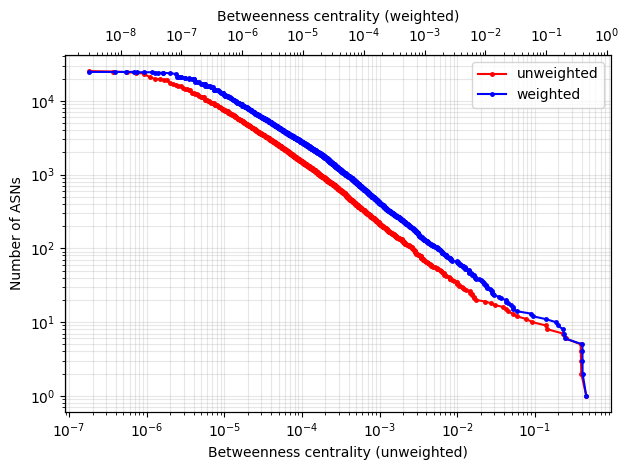

In [11]:
bc_uw_list = [v for v in global_graph_df["bc_uw"] if v > 0]
bc_uw_dist = Counter(bc_uw_list)
x_bc_uw = sorted(bc_uw_dist.keys())
y_bc_uw = []
remaining = len(bc_uw_list)
for xi in x_bc_uw:
    y_bc_uw.append(remaining)
    remaining -= bc_uw_dist[xi]

bc_w_list = [v for v in global_graph_df["bc_w"] if v > 0]
bc_w_dist = Counter(bc_w_list)
x_bc_w = sorted(bc_w_dist.keys())
y_bc_w = []
remaining = len(bc_w_list)
for xi in x_bc_w:
    y_bc_w.append(remaining)
    remaining -= bc_w_dist[xi]

fig, ax1 = plt.subplots()
ax1.plot(x_bc_uw, y_bc_uw, marker=".", markersize=5, color="red", label="unweighted")
ax1.set_xscale("log")
ax1.set_yscale("log")
ax1.set_xlabel("Betweenness centrality (unweighted)")
ax1.set_ylabel("Number of ASNs")

ax2 = ax1.twiny()
ax2.plot(x_bc_w, y_bc_w, marker=".", markersize=5, color="blue", label="weighted")
ax2.set_xscale("log")
ax2.set_xlabel("Betweenness centrality (weighted)")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2)
ax1.grid(True, which="both", alpha=0.3)
fig.tight_layout()
plt.show()

### Question 4
What shape does the CCDF have? What does this tell us about the distribution of weighted betweenness centralities?

YOUR ANSWER HERE

## Task 2: AS Hegemony

In this task you will:

1. Compute $BC_{(j)}(v)$ for each viewpoint $j$ and AS $v$;
2. Filter out VPs and compute quotients to calculate AS hegemony;
3. Create a scatter plot of AS hegemony vs. weighted betweenness centrality;
4. Answer some questions about the data.

In [12]:
def get_bcscore_per_viewpoint():
    pass 

In [13]:
ALPHA = 0.1

In [ ]:
ALPHA = 0.1                # fraction of viewpoints trimmed at each end (paper's value)
FULL_FEED_FRACTION = 0.75  # a viewpoint must carry >= this fraction of all announced IPv4 prefixes

vp_threshold = FULL_FEED_FRACTION * len(norm_weight)

# peer_counts (from pass 1) sums announcements across collectors, so a peer
# feeding two collectors is counted about twice here. That only overshoots,
# never undershoots: no genuine full feed is lost at this stage, and impostors
# are re-checked against their deduplicated route count after pass 3.
vp_meta = sorted(k for k, c in peer_counts.items() if c >= vp_threshold)
vp_index = {peer_ip: j for j, (peer_ip, _) in enumerate(vp_meta)}
num_vps = len(vp_meta)

print(f"{num_vps} candidate full-feed viewpoints "
      f"(>= {vp_threshold:,.0f} of {len(norm_weight):,} IPv4 prefixes) "
      f"in {len({asn for _, asn in vp_meta})} peer ASes, "
      f"out of {len(peer_counts)} peers total")

In [ ]:
# These three lines are included for efficiency reasons
gc.collect()
gc.freeze()
gc.disable()

t0 = time.time()
n_used = 0

routes_per_vp = {}     # map from ASes and VPs to count of routes
addresses_per_vp = {}  # map from ASes and VPs to weighted count of routes
# The following three lines behave like DefaultDicts. They are more
# memory efficient for this particular task
zero_row = array("q", [0]) * num_vps  # initialize everything to 0s
vp_total_u = array("q", zero_row)     # map from VPs to count of routes
vp_total_w = array("q", zero_row)     # map from VPs to weighted count of routes

# Table to ensure each route is considered only once
seen = SeenKeys(sum(c for (ip, _), c in peer_counts.items() if ip in vp_index))

for elem in iter_routes(RIB_PATHS, dedup=False, progress_every=0):
    j = vp_index.get(elem.peer_ip)

    # Filter out VPs that see few routes
    if j is None:
        continue
    # Filter out duplicate routes
    if not seen.add(hash((elem.peer_ip, elem.prefix))):
        continue

    w = weights.get(elem.prefix)

    # Filter out IPv6, default route, or unparseable prefix
    if w is None:
        continue
    path_str = elem.as_path
    # Filter out AS-set or missing path
    if path_str is None or "{" in path_str:
        continue

    n_used += 1
    if n_used % 5_000_000 == 0:
        print(f"  {n_used:,} viewpoint routes...")

    # Accumulate weight towards the denominator of BC_j(v)
    vp_total_u[j] += 1
    vp_total_w[j] += w

    path = []
    prev = None
    for hop in path_str.split():
        if hop != prev:  # collapse prepending
            path.append(hop)
            prev = hop

    for v in path[1:-1]:
        routes_acc = routes_per_vp.get(v)
        addresses_acc = addresses_per_vp.get(v)
        if addresses_acc is None:
            # In this case, routes_acc is also None
            routes_acc = routes_per_vp[v] = array("q", zero_row)
            addresses_acc = addresses_per_vp[v] = array("q", zero_row)

        # Accumulate weight towards the numerator of BC_j(v)
        routes_acc[j] += 1
        addresses_acc[j] += w

gc.enable()
gc.unfreeze()
print(f"{n_used:,} routes from {num_vps} candidate viewpoints, "
      f"{len(addresses_per_vp):,} ASes on-path ({time.time() - t0:.0f}s)")

In [ ]:
t0 = time.time()

# We only use VPs that have a full enough view of the global Internet
valid_vp_indices = [j for j in range(num_vps) if vp_total_u[j] >= vp_threshold]
n_vp = len(valid_vp_indices)
if n_vp == 0:
    raise RuntimeError("no full-feed viewpoints — lower FULL_FEED_FRACTION or add collectors")

# Find the number (alpha proprtion) of VPs to trim
### STUDENT CODE START
n_vps_to_trim = math.floor(ALPHA * n_vp)
### STUDENT CODE END

hege_rows = []
for asn_str, vp_w in addresses_per_vp.items():
    asn = int(asn_str)

    # For each viewpoint, compute the betweenness centrality of this asn
    vp_bc_w = sorted(vp_w[j] / vp_total_w[j] for j in valid_vp_indices)
    # Trim the top and bottom alpha proportion VPs and average
    hegemony = sum(vp_bc_w[n_vps_to_trim:n_vp - n_vps_to_trim]) / (n_vp - 2 * n_vps_to_trim)

    name, country = asn_info.get(asn, ("", ""))
    hege_rows.append({
        "asn": asn,
        "name": name[:48],
        "country": country,
        "hegemony": hegemony,
        "viewpoints": sum(1 for x in vp_bc_w if x > 0),
    })

hege_df = (pd.DataFrame(hege_rows)
             .sort_values("hegemony", ascending=False)
             .reset_index(drop=True))
hege_df.insert(0, "rank_w", hege_df.index + 1)
print(f"{len(hege_df):,} ASes scored ({time.time() - t0:.0f}s)")

hege_df.head(25).style.format({
    "hegemony": "{:.4f}",
}).hide(axis="index")

### Question 1
Why do we remove the top and bottom $\alpha$ proportions of the viewpoints?

YOUR ANSWER HERE

### Question 2
How do the top 5 ASes ranked by betweenness centrality compare to the top 5 ranked by AS hegemony?

YOUR ANSWER HERE

In [ ]:
both = df.merge(hege_df, on="asn", suffixes=("_bc", "_hege"))
pos = both[(both["bc_weighted"] > 0) & (both["hegemony"] > 0)]

fig, ax = plt.subplots(figsize=(6.5, 6))
fig.patch.set_facecolor(SURFACE)
style_axes(ax)

lo = max(min(pos["bc_weighted"].min(), pos["hegemony"].min()), 1e-9)
hi = max(pos["bc_weighted"].max(), pos["hegemony"].max()) * 2
ax.plot([lo, hi], [lo, hi], color=MUTED, linewidth=1, linestyle="--", zorder=1)
ax.annotate("equal under both metrics", xy=(hi, hi),
            xytext=(-8, -14), textcoords="offset points",
            ha="right", fontsize=8, color=MUTED)

ax.scatter(pos["bc_weighted"], pos["hegemony"],
           s=14, color=BLUE, alpha=0.45, linewidths=0, zorder=2)

asn_outlier = pos.iloc[(pos["bc_weighted"] / pos["hegemony"]).argmax()]
ax.annotate(f"AS{asn_outlier['asn']}", xy=(asn_outlier["bc_weighted"], asn_outlier["hegemony"]),
            xytext=(5, 3), textcoords="offset points",
            fontsize=8, color=INK2)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(lo, hi)
ax.set_ylim(lo, hi)
ax.set_xlabel("Weighted betweenness centrality", color=INK2)
ax.set_ylabel("AS hegemony", color=INK2)
fig.tight_layout()
plt.show()

### Question 3
What does the concentration of points on the $x = y$ line tell us about the relationship between betweenness centrality and AS hegemony?

YOUR ANSWER HERE

### Question 4
Look up the AS that corresponds to the outlier point. How does this AS's geographic location relate to the location of the collectors?

YOUR ANSWER HERE

### Question 5
Why does the geographic location of the outlier AS cause its betweenness centrality to be so much larger than its AS hegemony?

YOUR ANSWER HERE